<a href="https://colab.research.google.com/github/M-Santhoshkumar-2005/ITA0616-MACHINE-LEARNING-SLOT-A-/blob/main/PROBLEM_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

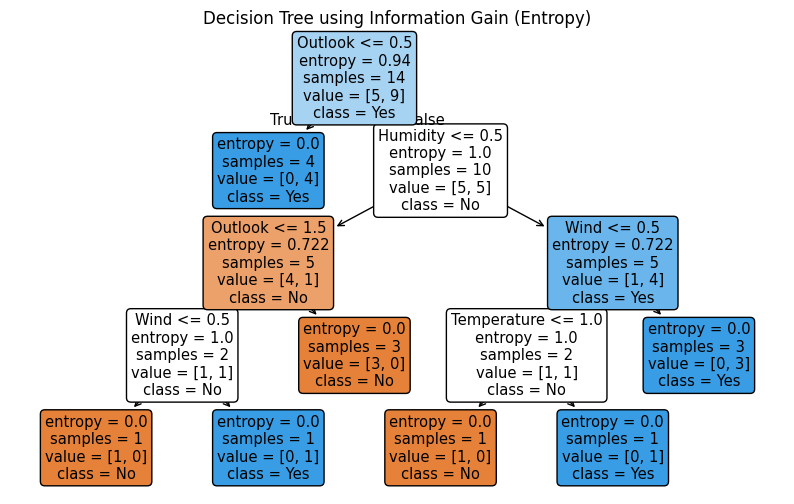


Predicted class for the new sample is: No


In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn import tree
import matplotlib.pyplot as plt


data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rain', 'Rain', 'Rain', 'Overcast',
                'Sunny', 'Sunny', 'Rain', 'Sunny', 'Overcast', 'Overcast', 'Rain'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool', 'Cool', 'Cool',
                    'Mild', 'Cool', 'Mild', 'Mild', 'Mild', 'Hot', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal', 'Normal', 'Normal',
                 'High', 'Normal', 'Normal', 'Normal', 'High', 'Normal', 'High'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong',
             'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong'],
    'PlayTennis': ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
                   'No', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No']
}
df = pd.DataFrame(data)


encoders = {}
for col in df.columns:
    encoders[col] = LabelEncoder()
    df[col] = encoders[col].fit_transform(df[col])

X = df.drop('PlayTennis', axis=1)
y = df['PlayTennis']


clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X, y)


plt.figure(figsize=(10, 6))
tree.plot_tree(clf, feature_names=X.columns,
               class_names=encoders['PlayTennis'].classes_,
               filled=True, rounded=True)
plt.title("Decision Tree using Information Gain (Entropy)")
plt.show()


new_sample = {
    'Outlook': ['Sunny'],
    'Temperature': ['Cool'],
    'Humidity': ['High'],
    'Wind': ['Strong']
}
new_df = pd.DataFrame(new_sample)


for col in new_df.columns:
    new_df[col] = encoders[col].transform(new_df[col])


prediction_numeric = clf.predict(new_df)
prediction_label = encoders['PlayTennis'].inverse_transform(prediction_numeric)

print(f"\nPredicted class for the new sample is: {prediction_label[0]}")